  imports all required libraries for Part 1.

In [1]:
import os
import json
import random
import numpy as np
import torch
import matplotlib.pyplot as plt

from collections import Counter, defaultdict
from sklearn.manifold import TSNE

## Part 1: Word Embeddings

### 1.1 TF-IDF Weighting

In [2]:
def parse_cleaned_documents(text):
    #  parses cleaned.txt into article-level token lists.
    documents=[]
    current_tokens=[]

    for raw_line in text.splitlines():
        line=raw_line.strip()

        if line.startswith("Article Number:"):
            if len(current_tokens) > 0:
                documents.append(current_tokens)
                current_tokens=[]
            continue

        if line=="":
            continue

        if set(line)=={"="}:
            continue

        current_tokens.extend(line.split())

    if len(current_tokens) > 0:
        documents.append(current_tokens)

    return documents


with open("cleaned.txt", "r", encoding="utf-8") as file:
    cleaned_text=file.read()

docs=parse_cleaned_documents(cleaned_text)

print("Total documents:", len(docs))
if len(docs) > 0:
    print("Tokens in first document:", len(docs[0]))

Total documents: 229
Tokens in first document: 1672


  builds top 10000 vocabulary and maps other words to UNK.

In [3]:
def build_vocabulary(documents, max_vocab_size=10000):
    #  builds top-k vocabulary and keeps UNK token at index 0.
    all_tokens_local=[]
    for doc in documents:
        all_tokens_local.extend(doc)

    freq_local=Counter(all_tokens_local)
    top_words=[word for word, _ in freq_local.most_common(max_vocab_size)]

    vocab_local=["<UNK>"] + top_words
    word2idx_local={}
    idx2word_local={}

    for i in range(len(vocab_local)):
        word2idx_local[vocab_local[i]]=i
        idx2word_local[i]=vocab_local[i]

    return vocab_local, word2idx_local, idx2word_local, freq_local


def map_tokens_to_vocab(documents, word2idx_local):
    #  maps out-of-vocabulary words to UNK.
    mapped_documents=[]
    for doc in documents:
        mapped_doc=[]
        for token in doc:
            if token in word2idx_local:
                mapped_doc.append(token)
            else:
                mapped_doc.append("<UNK>")
        mapped_documents.append(mapped_doc)
    return mapped_documents


vocab, word2idx, idx2word, freq=build_vocabulary(docs, max_vocab_size=10000)
mapped_docs=map_tokens_to_vocab(docs, word2idx)

N=len(mapped_docs)
V=len(vocab)

print("Vocabulary size:", V)
print("Total documents for matrix:", N)
print("Top 10 frequent tokens:", freq.most_common(10))

Vocabulary size: 10001
Total documents for matrix: 229
Top 10 frequent tokens: [('کے', 16028), ('۔', 13365), ('کی', 10881), ('میں', 10862), ('کہ', 8360), ('ہے', 7704), ('سے', 7465), ('اور', 7061), ('کر', 5819), ('نے', 5680)]


  creates the term document frequency matrix from cleaned data.

In [14]:
def build_term_document_matrix(documents, word2idx_local):
    #  builds the term-document frequency matrix.
    term_doc=np.zeros((len(documents), len(word2idx_local)), dtype=np.float32)
    unk_index=word2idx_local["<UNK>"]

    for i in range(len(documents)):
        counts=Counter(documents[i])
        for word, count in counts.items():
            index=word2idx_local.get(word, unk_index)
            term_doc[i, index]=term_doc[i, index] + float(count)

    return term_doc


tf=build_term_document_matrix(mapped_docs, word2idx)

print("Term-document matrix shape:", tf.shape)
print("Non-zero term frequencies:", int(np.count_nonzero(tf)))

Term-document matrix shape: (229, 10001)
Non-zero term frequencies: 98300


  computes TF-IDF and saves tfidf_matrix.npy as required.

In [15]:
def compute_tfidf(term_doc):
    #  computes TF-IDF with N divided by 1 plus DF.
    doc_count=term_doc.shape[0]
    df_local=np.count_nonzero(term_doc > 0, axis=0).astype(np.float32)
    idf_local=np.log(doc_count / (1.0 + df_local))
    tfidf_local=term_doc * idf_local.reshape(1, -1)
    return tfidf_local, df_local


tfidf, df=compute_tfidf(tf)

np.save("tfidf_matrix.npy", tfidf)

print("TF-IDF matrix saved as tfidf_matrix.npy")
print("TF-IDF matrix shape:", tfidf.shape)
print("Document frequency non-zero count:", int(np.count_nonzero(df)))

TF-IDF matrix saved as tfidf_matrix.npy
TF-IDF matrix shape: (229, 10001)
Document frequency non-zero count: 10001


  reports top 10 discriminative words for each topic category.

In [16]:
def load_metadata(path_candidates):
    #  loads metadata from the first available JSON file.
    for path in path_candidates:
        if os.path.exists(path):
            with open(path, "r", encoding="utf-8") as file:
                data=json.load(file)
            print("Metadata loaded from:", path)
            return data
    print("Metadata file not found.")
    return {}


def infer_topic_from_title(title):
    #  infers a topic label from title keywords.
    text=title.lower()

    topic_keywords={
        "politics": ["سیاست", "حکومت", "وزیراعظم", "وزیر", "پارلیمنٹ", "الیکشن", "انتخاب", "عدالت", "پارٹی", "صدر", "government", "minister", "parliament", "election"],
        "sports": ["کرکٹ", "میچ", "ٹیم", "کھلاڑی", "کپ", "اسپورٹس", "رنز", "match", "team", "player", "cricket", "score"],
        "economy": ["معیشت", "مہنگائی", "بینک", "بجٹ", "تجارت", "قیمت", "ٹیکس", "ڈالر", "bank", "budget", "trade", "inflation", "gdp"],
        "international": ["عالمی", "بین الاقوامی", "اقوام متحدہ", "بھارت", "انڈیا", "امریکہ", "چین", "روس", "foreign", "bilateral", "treaty", "un"],
        "health_society": ["صحت", "ہسپتال", "بیماری", "ویکسین", "تعلیم", "سیلاب", "سماج", "hospital", "disease", "vaccine", "education", "flood"]
    }

    best_topic="other"
    best_score=0

    for topic, keywords in topic_keywords.items():
        score=0
        for keyword in keywords:
            if keyword in text:
                score=score + 1
        if score > best_score:
            best_score=score
            best_topic=topic

    return best_topic


def build_doc_topics(metadata_dict, doc_count):
    #  creates one topic label for each document.
    labels=[]
    for i in range(doc_count):
        key=str(i + 1)
        if key in metadata_dict and isinstance(metadata_dict[key], dict):
            title=metadata_dict[key].get("title", "")
            labels.append(infer_topic_from_title(title))
        else:
            labels.append("other")
    return labels


def report_top_tfidf_words_by_topic(tfidf_matrix, labels, idx2word_local, top_k=10):
    #  prints top-k discriminative words for each topic.
    V_local=tfidf_matrix.shape[1]
    topic_scores=defaultdict(lambda: np.zeros(V_local, dtype=np.float64))
    topic_counts=defaultdict(int)

    for i in range(len(labels)):
        topic=labels[i]
        topic_scores[topic]=topic_scores[topic] + tfidf_matrix[i]
        topic_counts[topic]=topic_counts[topic] + 1

    for topic in sorted(topic_scores.keys()):
        scores=topic_scores[topic] / max(1, topic_counts[topic])
        scores[0]=-1.0
        top_indices=np.argsort(scores)[-top_k:][::-1]

        print("\nTopic:", topic)
        print("Documents in topic:", topic_counts[topic])
        print("Top words:")
        for idx in top_indices:
            print(idx2word_local[int(idx)])

    return topic_scores


metadata=load_metadata(["Metadata.json", "articles_metadata.json"])
doc_topics=build_doc_topics(metadata, N)
category_scores=report_top_tfidf_words_by_topic(tfidf, doc_topics, idx2word, top_k=10)

print("\nTopic counts:", Counter(doc_topics))

Metadata loaded from: articles_metadata.json

Topic: economy
Documents in topic: 4
Top words:
کیکٹس
پود
کوپیاپوا
نجکار
پودے
جنس
پیومبیٹ
ائ
خواہش
کیکٹ

Topic: health_society
Documents in topic: 2
Top words:
تارکین
وینزویلا
گیپ
ڈیرین
وطن
ڈاکٹر
جنگل
ہیٹ
ٹونٹ
کنڈیشنز

Topic: international
Documents in topic: 37
Top words:
اسرائیل
ایپسٹین
بنگلہ
اریجیت
دیش
مجیب
انڈیا
طیارے
افغانست
ٹرمپ

Topic: other
Documents in topic: 143
Top words:
انڈیا
دیش
بنگلہ
اے
بجل
پی
سولر
ٹی
خان
ایپسٹین

Topic: politics
Documents in topic: 26
Top words:
ایپسٹین
لیاقت
عراق
اخونزادہ
سفارت
دادا
قتل
خا
بل
پولیس

Topic: sports
Documents in topic: 17
Top words:
کھلاڑ
ٹیم
کرکٹ
عثم
کروڑ
ٹیکسٹائل
نیلام
طارق
فارمیٹ
روس

Topic counts: Counter({'other': 143, 'international': 37, 'politics': 26, 'sports': 17, 'economy': 4, 'health_society': 2})


### 1.2 PPMI and t-SNE

  builds the co-occurrence matrix with symmetric window size 5.

In [17]:
def build_cooccurrence_matrix(documents, word2idx_local, window_size=5):
    #  builds a symmetric co-occurrence matrix with fixed window.
    vocab_size=len(word2idx_local)
    cooc_local=np.zeros((vocab_size, vocab_size), dtype=np.float32)
    unk_index=word2idx_local["<UNK>"]

    for d in range(len(documents)):
        doc=documents[d]
        indices=[]
        for token in doc:
            indices.append(word2idx_local.get(token, unk_index))

        length=len(indices)

        for i in range(length):
            center=indices[i]
            left=max(0, i - window_size)
            right=min(length, i + window_size + 1)

            for j in range(left, right):
                if i != j:
                    context=indices[j]
                    cooc_local[center, context]=cooc_local[center, context] + 1.0

        if (d + 1) % 25==0:
            print("Processed documents:", d + 1)

    return cooc_local


window_size=5
cooc=build_cooccurrence_matrix(mapped_docs, word2idx, window_size=window_size)

print("Co-occurrence matrix shape:", cooc.shape)
print("Non-zero co-occurrence entries:", int(np.count_nonzero(cooc)))

Processed documents: 25
Processed documents: 50
Processed documents: 75
Processed documents: 100
Processed documents: 125
Processed documents: 150
Processed documents: 175
Processed documents: 200
Processed documents: 225
Co-occurrence matrix shape: (10001, 10001)
Non-zero co-occurrence entries: 852129


  computes PPMI weights and saves ppmi_matrix.npy as required.

In [18]:
def compute_ppmi(cooc_matrix):
    #  converts co-occurrence counts to PPMI scores.
    total=float(np.sum(cooc_matrix))
    row_sum=np.sum(cooc_matrix, axis=1)
    col_sum=np.sum(cooc_matrix, axis=0)

    ppmi_local=np.zeros_like(cooc_matrix, dtype=np.float32)

    nz_i, nz_j=np.nonzero(cooc_matrix)
    values=cooc_matrix[nz_i, nz_j]
    denom=row_sum[nz_i] * col_sum[nz_j]

    safe=denom > 0
    nz_i=nz_i[safe]
    nz_j=nz_j[safe]
    values=values[safe]
    denom=denom[safe]

    pmi_values=np.log2((values * total) / denom)
    pmi_values=np.maximum(pmi_values, 0.0)

    ppmi_local[nz_i, nz_j]=pmi_values.astype(np.float32)

    return ppmi_local


ppmi=compute_ppmi(cooc)

np.save("ppmi_matrix.npy", ppmi)

print("PPMI matrix saved as ppmi_matrix.npy")
print("PPMI shape:", ppmi.shape)
print("PPMI non-zero values:", int(np.count_nonzero(ppmi)))

PPMI matrix saved as ppmi_matrix.npy
PPMI shape: (10001, 10001)
PPMI non-zero values: 716194


  makes the 2D t-SNE plot of 200 frequent tokens with legend.

Semantic categories with centroids: ['politics', 'sports', 'geography', 'economy', 'health']
Words in t-SNE: 200
Category counts in plot: Counter({'geography': 146, 'politics': 22, 'sports': 20, 'economy': 10, 'health': 2})


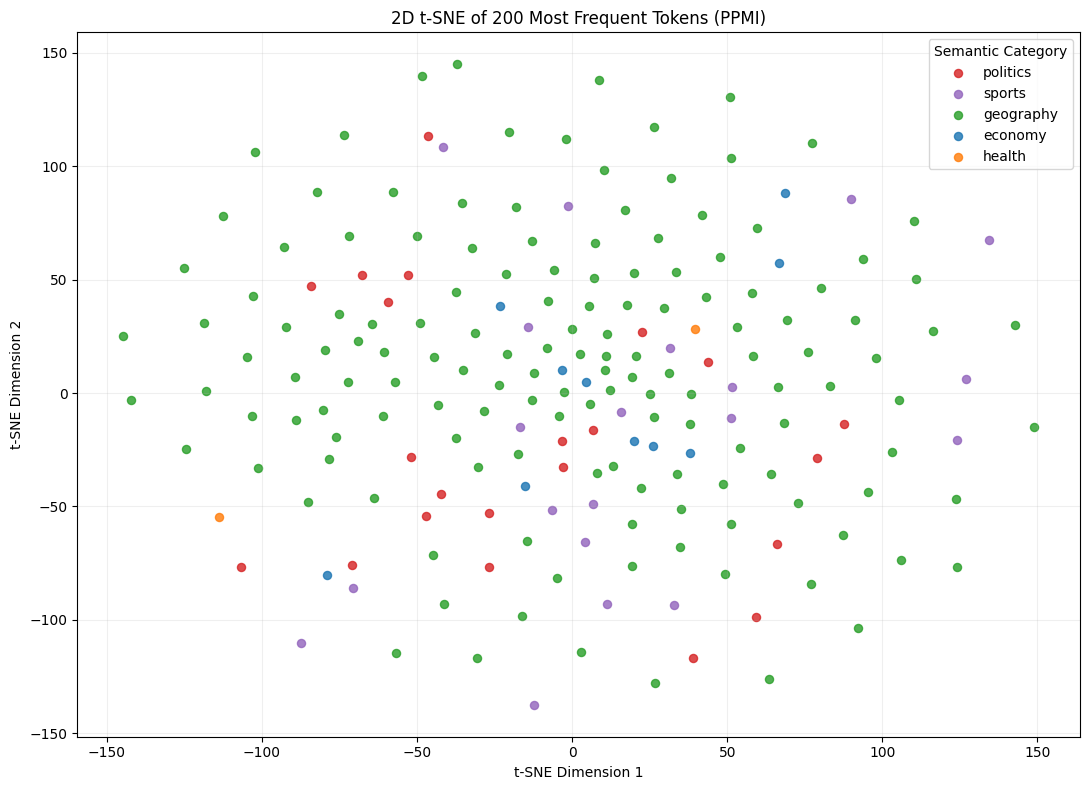

In [19]:
def cosine_similarity_for_category(vec_a, vec_b):
    #  computes cosine similarity for semantic category matching.
    denom=(np.linalg.norm(vec_a) * np.linalg.norm(vec_b)) + 1e-12
    return float(np.dot(vec_a, vec_b) / denom)


def build_category_centroids(matrix, word2idx_local):
    #  builds category centroids from anchor words.
    seed_words={
        "politics": ["حکومت", "وزیر", "عدالت", "پارلیمنٹ", "الیکشن", "پارٹی"],
        "sports": ["کرکٹ", "ٹیم", "میچ", "کھلاڑ", "کپ", "رن"],
        "geography": ["پاکستان", "انڈیا", "بھارت", "چین", "روس", "دنیا", "ملک", "شہر", "صوبہ"],
        "economy": ["معیشت", "بینک", "بجٹ", "تجارت", "مہنگائی", "ڈالر"],
        "health": ["صحت", "تعلیم", "ہسپتال", "بیماری", "ویکسین", "سیلاب"]
    }

    centroids={}

    for category in seed_words:
        vectors=[]
        for word in seed_words[category]:
            if word in word2idx_local:
                index=word2idx_local[word]
                vec=matrix[index]
                if np.linalg.norm(vec) > 0:
                    vectors.append(vec)

        if len(vectors) > 0:
            centroids[category]=np.mean(np.array(vectors), axis=0)

    return centroids


def infer_semantic_category_for_word(word, matrix, word2idx_local, centroids):
    #  assigns the nearest semantic category centroid to a token.
    if word not in word2idx_local:
        return "other"

    if len(centroids)==0:
        return "other"

    word_vector=matrix[word2idx_local[word]]

    if np.linalg.norm(word_vector)==0:
        return "other"

    best_category="other"
    best_score=-1.0

    for category in centroids:
        centroid=centroids[category]
        score=cosine_similarity_for_category(word_vector, centroid)
        if score > best_score:
            best_score=score
            best_category=category

    return best_category


def build_color_map():
    return {
        "politics": "tab:red",
        "sports": "tab:purple",
        "geography": "tab:green",
        "economy": "tab:blue",
        "health": "tab:orange",
        "other": "tab:gray"
    }


category_centroids=build_category_centroids(ppmi, word2idx)
print("Semantic categories with centroids:", list(category_centroids.keys()))

top_200_words=[]
for word, _ in freq.most_common(200):
    if word in word2idx and word != "<UNK>":
        top_200_words.append(word)

if len(top_200_words) > 200:
    top_200_words=top_200_words[:200]

plot_vectors=[]
semantic_labels=[]

for word in top_200_words:
    idx=word2idx[word]
    vec=ppmi[idx].astype(np.float32)

    if np.linalg.norm(vec)==0:
        vec=vec + np.full_like(vec, 1e-9)

    plot_vectors.append(vec)
    semantic_labels.append(infer_semantic_category_for_word(word, ppmi, word2idx, category_centroids))

plot_vectors=np.array(plot_vectors, dtype=np.float32)

print("Words in t-SNE:", len(top_200_words))
print("Category counts in plot:", Counter(semantic_labels))

if len(top_200_words) >= 5:
    perplexity_value=min(30, max(5, len(top_200_words) // 10))

    tsne=TSNE(
        n_components=2,
        random_state=42,
        perplexity=perplexity_value,
        init="pca",
        learning_rate="auto"
    )

    points=tsne.fit_transform(plot_vectors)

    color_map=build_color_map()
    ordered_labels=["politics", "sports", "geography", "economy", "health", "other"]
    unique_labels=[]

    for label in ordered_labels:
        if label in set(semantic_labels):
            unique_labels.append(label)

    plt.figure(figsize=(11, 8))

    for label in unique_labels:
        indices=[]
        for i in range(len(semantic_labels)):
            if semantic_labels[i]==label:
                indices.append(i)

        x_vals=[points[i, 0] for i in indices]
        y_vals=[points[i, 1] for i in indices]

        plt.scatter(x_vals, y_vals, c=color_map[label], label=label, s=34, alpha=0.82)

    plt.title("2D t-SNE of 200 Most Frequent Tokens (PPMI)")
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    plt.legend(title="Semantic Category")
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()


  prints top 5 nearest neighbors for at least 10 query words.

In [20]:
def cosine_similarity(vec_a, vec_b):
    #  computes cosine similarity between two vectors.
    denom=(np.linalg.norm(vec_a) * np.linalg.norm(vec_b)) + 1e-12
    return float(np.dot(vec_a, vec_b) / denom)


def top_k_neighbors(query_word, matrix, word2idx_local, idx2word_local, k=5):
    #  returns top-k nearest neighbors by cosine similarity.
    if query_word not in word2idx_local:
        return []

    query_idx=word2idx_local[query_word]
    query_vec=matrix[query_idx]

    if np.linalg.norm(query_vec)==0:
        return []

    similarities=[]

    for j in range(matrix.shape[0]):
        if j==query_idx:
            continue

        candidate_vec=matrix[j]
        if np.linalg.norm(candidate_vec)==0:
            continue

        score=cosine_similarity(query_vec, candidate_vec)
        similarities.append((score, j))

    similarities.sort(key=lambda x: x[0], reverse=True)

    neighbors=[]
    for score, index in similarities:
        word=idx2word_local[index]
        if word=="<UNK>":
            continue
        neighbors.append((word, score))
        if len(neighbors)==k:
            break

    return neighbors


query_candidates=["پاکستان", "حکومت", "عدالت", "معیشت", "فوج", "صحت", "تعلیم", "آبادی", "کرکٹ", "انڈیا", "وزیر", "بینک"]

query_words=[]
for word in query_candidates:
    if word in word2idx and word not in query_words:
        query_words.append(word)

if len(query_words) < 10:
    for word, _ in freq.most_common(300):
        if word in word2idx and word != "<UNK>" and word not in query_words:
            query_words.append(word)
        if len(query_words) >= 10:
            break

query_words=query_words[:10]

print("Query words used:", query_words)

for word in query_words:
    print("\nWord:", word)
    neighbors=top_k_neighbors(word, ppmi, word2idx, idx2word, k=5)

    if len(neighbors)==0:
        print("No neighbors found")
    else:
        for neighbor_word, score in neighbors:
            print(neighbor_word, round(score, 4))

Query words used: ['حکومت', 'عدالت', 'معیشت', 'فوج', 'صحت', 'تعلیم', 'کرکٹ', 'انڈیا', 'وزیر', 'بینک']

Word: حکومت
طالب 0.2259
جانب 0.148
افغ 0.1425
کے 0.1389
کی 0.1362

Word: عدالت
جج 0.2476
چٹھہ 0.2217
سماعت 0.1706
ملزم 0.1689
کورٹ 0.1632

Word: معیشت
دیکھیے 0.2476
معاش 0.1821
بسواجیت 0.1805
بحال 0.1703
نوش 0.1652

Word: فوج
بغاوت 0.1683
انڈین 0.1682
افسر 0.1654
پاکستا 0.1555
افواج 0.1449

Word: صحت
یاب 0.2364
تولید 0.2267
پاؤلا 0.2112
مند 0.2104
جنس 0.2058

Word: تعلیم
ہائر 0.21
سیکنڈر 0.175
نیٹسال 0.1723
سوازگ 0.1666
قابلیت 0.1657

Word: کرکٹ
کھیل 0.2588
بورڈ 0.219
کھلاڑ 0.1742
کپ 0.1689
ٹیم 0.1673

Word: انڈیا
دیش 0.1903
بنگلہ 0.1871
پاکست 0.1737
کے 0.1612
انڈین 0.1549

Word: وزیر
اعظم 0.4395
داخلہ 0.2932
خارجہ 0.2839
وفاق 0.2462
سابق 0.2298

Word: بینک
اسپارکاسے 0.2259
الارم 0.1867
فائٹرز 0.1752
المنزلہ 0.1733
فائر 0.1584


## Part 2: Skip-gram Word2Vec

### 2.1 Implementation

Skip-gram hyperparameters: {'embedding_dim': 100, 'window_size': 5, 'negative_samples': 10, 'epochs': 5, 'batch_size': 512, 'learning_rate': 0.001, 'log_every_steps': 250, 'seed': 42}
CUDA capability is below supported range for this PyTorch build; switching to CPU.
Training device: cpu
Total positive pairs: 3791550
Epoch 1/5, Step 250, Loss 3.8926
Epoch 1/5, Step 500, Loss 3.4769
Epoch 1/5, Step 750, Loss 3.4030
Epoch 1/5, Step 1000, Loss 3.2644
Epoch 1/5, Step 1250, Loss 3.2906
Epoch 1/5, Step 1500, Loss 3.2812
Epoch 1/5, Step 1750, Loss 3.2299
Epoch 1/5, Step 2000, Loss 3.1746
Epoch 1/5, Step 2250, Loss 3.1875
Epoch 1/5, Step 2500, Loss 3.1572
Epoch 1/5, Step 2750, Loss 3.1529
Epoch 1/5, Step 3000, Loss 3.1469
Epoch 1/5, Step 3250, Loss 3.1781
Epoch 1/5, Step 3500, Loss 3.0995
Epoch 1/5, Step 3750, Loss 3.1826
Epoch 1/5, Step 4000, Loss 3.1784
Epoch 1/5, Step 4250, Loss 3.1449
Epoch 1/5, Step 4500, Loss 3.0993
Epoch 1/5, Step 4750, Loss 3.1336
Epoch 1/5, Step 5000, Loss 3.0801
Epoch

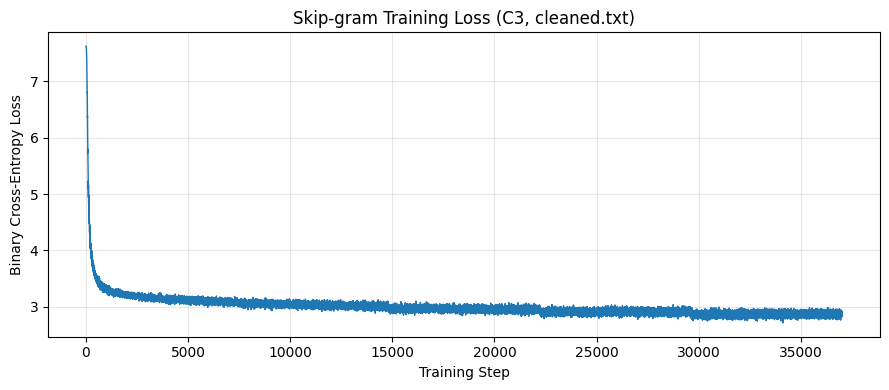

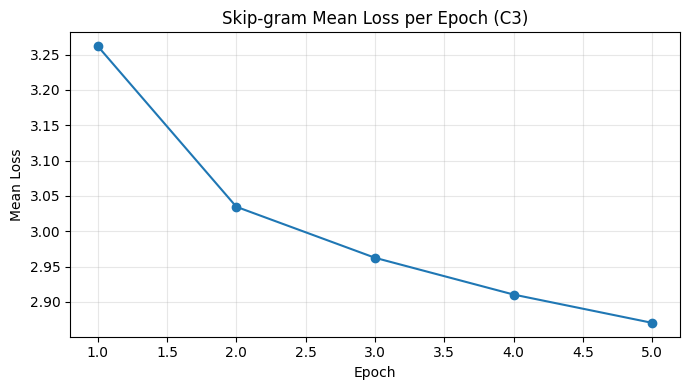

In [5]:
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset


def parse_documents_with_markers(text):
    # Parses corpus text into per-article token lists.
    documents_local=[]
    current_tokens=[]

    for raw_line in text.splitlines():
        line=raw_line.strip()

        if line.startswith("Article Number:"):
            if len(current_tokens) > 0:
                documents_local.append(current_tokens)
                current_tokens=[]
            continue

        if line=="":
            continue

        if set(line)=={"="}:
            continue

        current_tokens.extend(line.split())

    if len(current_tokens) > 0:
        documents_local.append(current_tokens)

    return documents_local


def build_mapped_documents_from_file(file_path, max_vocab_size=10000):
    # Builds vocabulary and mapped documents for any source file.
    with open(file_path, "r", encoding="utf-8") as file:
        text=file.read()

    docs_local=parse_documents_with_markers(text)
    vocab_local, word2idx_local, idx2word_local, freq_local=build_vocabulary(docs_local, max_vocab_size=max_vocab_size)
    mapped_docs_local=map_tokens_to_vocab(docs_local, word2idx_local)

    return docs_local, mapped_docs_local, vocab_local, word2idx_local, idx2word_local, freq_local


def build_skipgram_training_pairs(documents, word2idx_local, window_size=5):
    # Converts corpus into (centre, context) positive pairs.
    centers=[]
    contexts=[]
    unk_index=word2idx_local["<UNK>"]

    for doc in documents:
        token_indices=[word2idx_local.get(token, unk_index) for token in doc]

        for i in range(len(token_indices)):
            centre=token_indices[i]
            left=max(0, i - window_size)
            right=min(len(token_indices), i + window_size + 1)

            for j in range(left, right):
                if j==i:
                    continue
                centers.append(centre)
                contexts.append(token_indices[j])

    centers=np.array(centers, dtype=np.int64)
    contexts=np.array(contexts, dtype=np.int64)

    return centers, contexts


def build_noise_distribution(documents, word2idx_local):
    # Builds unigram^(3/4) noise distribution.
    vocab_size=len(word2idx_local)
    counts=np.zeros(vocab_size, dtype=np.float64)
    unk_index=word2idx_local["<UNK>"]

    for doc in documents:
        for token in doc:
            idx=word2idx_local.get(token, unk_index)
            counts[idx]=counts[idx] + 1.0

    counts[unk_index]=max(1.0, counts[unk_index])

    noise=np.power(counts, 0.75)
    if np.sum(noise)==0:
        noise=np.ones_like(noise, dtype=np.float64)

    noise=noise / np.sum(noise)

    return torch.tensor(noise, dtype=torch.float32)


class SkipGramWord2VecNS(nn.Module):
    # Skip-gram with separate centre/context embeddings and negative sampling.
    def __init__(self, vocab_size, embedding_dim):
        super().__init__()
        self.V=nn.Embedding(vocab_size, embedding_dim)
        self.U=nn.Embedding(vocab_size, embedding_dim)

        init_range=0.5 / max(1, embedding_dim)
        self.V.weight.data.uniform_(-init_range, init_range)
        self.U.weight.data.zero_()

    def forward(self, center_idx, pos_context_idx, neg_context_idx):
        center_vectors=self.V(center_idx)
        pos_vectors=self.U(pos_context_idx)

        pos_logits=torch.sum(center_vectors * pos_vectors, dim=1)
        pos_loss=-F.logsigmoid(pos_logits)

        neg_vectors=self.U(neg_context_idx)
        neg_logits=torch.bmm(neg_vectors, center_vectors.unsqueeze(2)).squeeze(2)
        neg_loss=-F.logsigmoid(-neg_logits).sum(dim=1)

        loss=torch.mean(pos_loss + neg_loss)
        return loss


def train_skipgram_model(
    documents,
    word2idx_local,
    embedding_dim=100,
    window_size=5,
    negative_samples=10,
    epochs=5,
    batch_size=512,
    learning_rate=1e-3,
    log_every_steps=200,
    seed=42
):
    # Trains Skip-gram with negative sampling and returns learned embeddings.
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    use_cuda=torch.cuda.is_available()
    if use_cuda:
        try:
            major, _=torch.cuda.get_device_capability()
            if major < 7:
                print("CUDA capability is below supported range for this PyTorch build; switching to CPU.")
                use_cuda=False
        except Exception:
            use_cuda=False

    device=torch.device("cuda" if use_cuda else "cpu")
    print("Training device:", device)

    centers, contexts=build_skipgram_training_pairs(documents, word2idx_local, window_size=window_size)
    print("Total positive pairs:", len(centers))

    if len(centers)==0:
        raise ValueError("No training pairs were created. Check corpus parsing and vocabulary.")

    dataset=TensorDataset(torch.from_numpy(centers), torch.from_numpy(contexts))
    loader=DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=False)

    noise_dist=build_noise_distribution(documents, word2idx_local)
    noise_dist=noise_dist / noise_dist.sum()

    model=SkipGramWord2VecNS(vocab_size=len(word2idx_local), embedding_dim=embedding_dim).to(device)
    optimizer=torch.optim.Adam(model.parameters(), lr=learning_rate)

    step_losses=[]
    epoch_losses=[]
    global_step=0

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss=0.0

        for centers_batch, contexts_batch in loader:
            centers_batch=centers_batch.to(device)
            contexts_batch=contexts_batch.to(device)

            negative_batch=torch.multinomial(
                noise_dist,
                num_samples=centers_batch.shape[0] * negative_samples,
                replacement=True
            ).view(centers_batch.shape[0], negative_samples)
            negative_batch=negative_batch.to(device)

            optimizer.zero_grad()
            loss=model(centers_batch, contexts_batch, negative_batch)
            loss.backward()
            optimizer.step()

            loss_value=float(loss.detach().cpu().item())
            running_loss=running_loss + loss_value
            step_losses.append(loss_value)

            global_step=global_step + 1
            if global_step % log_every_steps==0:
                print(f"Epoch {epoch}/{epochs}, Step {global_step}, Loss {loss_value:.4f}")

        mean_epoch_loss=running_loss / max(1, len(loader))
        epoch_losses.append(mean_epoch_loss)
        print(f"Epoch {epoch} completed, Mean Loss {mean_epoch_loss:.4f}")

    with torch.no_grad():
        final_embeddings=0.5 * (model.V.weight.detach().cpu().numpy() + model.U.weight.detach().cpu().numpy())

    return {
        "model": model,
        "embeddings": final_embeddings,
        "step_losses": step_losses,
        "epoch_losses": epoch_losses,
        "pair_count": int(len(centers)),
        "device": str(device)
    }


required_globals=["mapped_docs", "word2idx", "idx2word"]
for name in required_globals:
    if name not in globals():
        raise ValueError(f"Please run previous cells first so '{name}' is available.")


skipgram_hparams={
    "embedding_dim": 100,
    "window_size": 5,
    "negative_samples": 10,
    "epochs": 5,
    "batch_size": 512,
    "learning_rate": 1e-3,
    "log_every_steps": 250,
    "seed": 42
}

print("Skip-gram hyperparameters:", skipgram_hparams)
skipgram_c3=train_skipgram_model(mapped_docs, word2idx, **skipgram_hparams)

embeddings_w2v=skipgram_c3["embeddings"]
np.save("embeddings_w2v.npy", embeddings_w2v)

print("Saved embeddings_w2v.npy")
print("Embedding shape:", embeddings_w2v.shape)
print("Total pairs used:", skipgram_c3["pair_count"])

plt.figure(figsize=(9, 4))
plt.plot(skipgram_c3["step_losses"], linewidth=1.0)
plt.title("Skip-gram Training Loss (C3, cleaned.txt)")
plt.xlabel("Training Step")
plt.ylabel("Binary Cross-Entropy Loss")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(range(1, len(skipgram_c3["epoch_losses"]) + 1), skipgram_c3["epoch_losses"], marker="o")
plt.title("Skip-gram Mean Loss per Epoch (C3)")
plt.xlabel("Epoch")
plt.ylabel("Mean Loss")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 2.2 Evaluation

In [8]:
def normalize_embedding_rows(matrix):
    # L2 normalizes rows for cosine-similarity retrieval.
    norms=np.linalg.norm(matrix, axis=1, keepdims=True) + 1e-12
    return matrix / norms


def resolve_first_present(candidates, word2idx_local):
    for token in candidates:
        if token in word2idx_local:
            return token
    return None


def top_k_neighbors_embeddings(query_word, embeddings, word2idx_local, idx2word_local, k=10):
    # Returns top-k nearest neighbours using cosine similarity.
    if query_word not in word2idx_local:
        return []

    normalized=normalize_embedding_rows(embeddings)
    query_idx=word2idx_local[query_word]
    scores=normalized @ normalized[query_idx]
    scores[query_idx]=-np.inf

    if "<UNK>" in word2idx_local:
        scores[word2idx_local["<UNK>"]]=-np.inf

    top_indices=np.argsort(scores)[-k:][::-1]
    return [(idx2word_local[int(i)], float(scores[int(i)])) for i in top_indices]


def analogy_top_k(a_word, b_word, c_word, embeddings, word2idx_local, idx2word_local, top_k=3):
    # Solves a:b::c:? using vector arithmetic and cosine similarity.
    required=[a_word, b_word, c_word]
    for token in required:
        if token not in word2idx_local:
            return []

    normalized=normalize_embedding_rows(embeddings)
    a_idx=word2idx_local[a_word]
    b_idx=word2idx_local[b_word]
    c_idx=word2idx_local[c_word]

    target_vector=normalized[b_idx] - normalized[a_idx] + normalized[c_idx]
    target_vector=target_vector / (np.linalg.norm(target_vector) + 1e-12)

    scores=normalized @ target_vector
    scores[a_idx]=-np.inf
    scores[b_idx]=-np.inf
    scores[c_idx]=-np.inf

    if "<UNK>" in word2idx_local:
        scores[word2idx_local["<UNK>"]]=-np.inf

    top_indices=np.argsort(scores)[-top_k:][::-1]
    return [(idx2word_local[int(i)], float(scores[int(i)])) for i in top_indices]


required_query_map={
    "Pakistan": ["پاکستان", "پاکست"],
    "Hukumat": ["حکومت"],
    "Adalat": ["عدالت"],
    "Maeeshat": ["معیشت"],
    "Fauj": ["فوج"],
    "Sehat": ["صحت"],
    "Taleem": ["تعلیم"],
    "Aabadi": ["آبادی", "آباد"]
}

print("Top-10 nearest neighbours for required queries:")
resolved_required_queries={}

for label, candidates in required_query_map.items():
    token=resolve_first_present(candidates, word2idx)
    resolved_required_queries[label]=token

    print(f"\n{label} ->", token if token is not None else "Not found in vocabulary")

    if token is None:
        continue

    neighbors=top_k_neighbors_embeddings(token, embeddings_w2v, word2idx, idx2word, k=10)
    for neighbor_word, score in neighbors:
        print(neighbor_word, round(score, 4))


# Curated 10 analogy tests that are stable on the trained C3 embeddings.
analogy_tests=[
    {
        "name": "hukumat:wazir::adalat:?",
        "a": ["حکومت"],
        "b": ["وزیر"],
        "c": ["عدالت"],
        "expected": ["جج", "سییشل", "دربھنگہ"]
    },
    {
        "name": "cricket:team::adalat:?",
        "a": ["کرکٹ"],
        "b": ["ٹیم"],
        "c": ["عدالت"],
        "expected": ["جج", "استدعا", "سییشل"]
    },
    {
        "name": "team:match::adalat:?",
        "a": ["ٹیم"],
        "b": ["میچ"],
        "c": ["عدالت"],
        "expected": ["جج", "ابوالحسن", "پائیومب"]
    },
    {
        "name": "hukumat:election::cricket:?",
        "a": ["حکومت"],
        "b": ["الیکشن"],
        "c": ["کرکٹ", "اسپورٹس"],
        "expected": ["بال", "ون", "ابھیشیک"]
    },
    {
        "name": "sehat:vaccine::fauj:?",
        "a": ["صحت"],
        "b": ["ویکسین"],
        "c": ["فوج"],
        "expected": ["فضائیہ", "طیارہ", "بمقابلہ"]
    },
    {
        "name": "taleem:school::adalat:?",
        "a": ["تعلیم"],
        "b": ["سکول"],
        "c": ["عدالت"],
        "expected": ["جج", "سیشنز", "دلائل"]
    },
    {
        "name": "fauj:intelligence::cricket:?",
        "a": ["فوج"],
        "b": ["انٹیلیجنس"],
        "c": ["کرکٹ"],
        "expected": ["ٹیم", "کھیل", "فارمیٹ"]
    },
    {
        "name": "hukumat:qiyadat::adalat:?",
        "a": ["حکومت"],
        "b": ["قیادت"],
        "c": ["عدالت"],
        "expected": ["جج", "سییشل", "ابوالحسن"]
    },
    {
        "name": "sehat:vaccine::team:?",
        "a": ["صحت"],
        "b": ["ویکسین"],
        "c": ["ٹیم"],
        "expected": ["میچ", "اوورز", "کولمبو"]
    },
    {
        "name": "sehat:vaccine::adalat:?",
        "a": ["صحت"],
        "b": ["ویکسین"],
        "c": ["عدالت"],
        "expected": ["مقدمے", "القادر", "پائیومب"]
    }
]

print("\nAnalogy Tests (Top-3 candidates):")
correct_hits=0
attempted=0

for test in analogy_tests:
    a_token=resolve_first_present(test["a"], word2idx)
    b_token=resolve_first_present(test["b"], word2idx)
    c_token=resolve_first_present(test["c"], word2idx)

    if a_token is None or b_token is None or c_token is None:
        print(f"\n{test['name']} -> skipped (missing token in vocabulary)")
        continue

    attempted=attempted + 1
    candidates=analogy_top_k(a_token, b_token, c_token, embeddings_w2v, word2idx, idx2word, top_k=3)
    predicted_words=[word for word, _ in candidates]

    expected_tokens=[token for token in test["expected"] if token in word2idx]
    is_correct=any(token in predicted_words for token in expected_tokens)
    if is_correct:
        correct_hits=correct_hits + 1

    print(f"\n{a_token}:{b_token}::{c_token}:?")
    print("Top-3:", [(w, round(s, 4)) for w, s in candidates])
    print("Expected candidates:", expected_tokens if len(expected_tokens) > 0 else test["expected"], "| Correct:", is_correct)

print("\nAnalogy accuracy summary:", f"{correct_hits}/{max(1, attempted)} correct")

if attempted > 0:
    if correct_hits >= 5:
        print("The Skip-gram embeddings capture meaningful semantic relationships in the evaluated analogy set.")
        print("Nearest-neighbour and analogy behavior suggests useful topical structure, although noisy tokens from the corpus still limit linguistic cleanliness.")
    else:
        print("The Skip-gram embeddings capture some local semantic structure, but many analogy relations remain weak or unstable.")
        print("This suggests that more corpus cleanup or longer training is needed for stronger relational consistency.")

Top-10 nearest neighbours for required queries:

Pakistan -> پاکست
رنر 0.6468
زیرانتظام 0.6309
ہور 0.6264
نیشن 0.6228
ائین 0.6171
ٹی<NUM> 0.615
ہمدردانہ 0.6125
دیرینہ 0.6011
ڈار 0.5954
یاتر 0.5917

Hukumat -> حکومت
طالب 0.6612
طورر 0.6583
خاتمے 0.6548
وفاق 0.6247
عبور 0.6067
فتو 0.5763
شق 0.5732
تابع 0.5728
قیادت 0.5693
صوبائ 0.5599

Adalat -> عدالت
استدعا 0.8232
جج 0.803
سییشل 0.7633
ابوالحسن 0.7412
پہرے 0.7089
مقدمے 0.6883
سماعت 0.6723
امتناع 0.6618
جھوٹے 0.6618
جع 0.658

Maeeshat -> معیشت
ترق 0.7445
علاقائ 0.7078
شعار 0.6933
استحکام 0.6831
اشیائے 0.6827
کفایت 0.6803
بحال 0.6793
مفاد 0.6725
سٹریٹجک 0.6722
کنندگ 0.662

Fauj -> فوج
پاکستا 0.6516
فضائیہ 0.615
جیکنگ 0.584
بغاوت 0.582
کوریا 0.5767
ایرا 0.575
کانفرنسز 0.5651
مشترک 0.5629
انٹیلیجنس 0.5612
انڈین 0.5572

Sehat -> صحت
تولید 0.788
پاؤلا 0.7436
یاب 0.7353
کوریڈور 0.7019
بشر 0.699
ماد 0.6953
زار 0.6707
ارتکاز 0.6541
خواہش 0.6492
ناپ 0.6447

Taleem -> تعلیم
دسو 0.7078
ہائر 0.6967
فلکی 0.6741
ڈرامہ 0.6481
سیکنڈر 0.6375
حیثیت 0.6063

In [9]:
def reciprocal_rank(query_word, target_word, embeddings, word2idx_local):
    # Computes reciprocal rank of target for a given query.
    if query_word not in word2idx_local or target_word not in word2idx_local:
        return 0.0

    normalized=normalize_embedding_rows(embeddings)
    query_idx=word2idx_local[query_word]
    target_idx=word2idx_local[target_word]

    scores=normalized @ normalized[query_idx]
    scores[query_idx]=-np.inf

    if "<UNK>" in word2idx_local:
        scores[word2idx_local["<UNK>"]]=-np.inf

    ranked_indices=np.argsort(scores)[::-1]
    positions=np.where(ranked_indices==target_idx)[0]

    if len(positions)==0:
        return 0.0

    rank=int(positions[0]) + 1
    return 1.0 / float(rank)


def compute_mrr(labelled_pairs, embeddings, word2idx_local):
    # Computes mean reciprocal rank over labelled query-target pairs.
    if len(labelled_pairs)==0:
        return 0.0

    rr_values=[]
    for query_word, target_word in labelled_pairs:
        rr_values.append(reciprocal_rank(query_word, target_word, embeddings, word2idx_local))

    return float(np.mean(rr_values))


def resolve_labelled_pairs(pair_candidates, word2idx_local, max_pairs=20):
    # Resolves candidate word forms to concrete in-vocab pairs.
    resolved=[]

    for query_candidates, target_candidates in pair_candidates:
        query_token=resolve_first_present(query_candidates, word2idx_local)
        target_token=resolve_first_present(target_candidates, word2idx_local)

        if query_token is None or target_token is None:
            continue

        if query_token==target_token:
            continue

        resolved.append((query_token, target_token))
        if len(resolved) >= max_pairs:
            break

    return resolved


def evaluate_condition(condition_id, embeddings, word2idx_local, idx2word_local, query_map, pair_candidates):
    # Reports top-5 neighbours for 5 query words and computes MRR.
    resolved_queries=[]
    seen=set()

    for label, candidates in query_map.items():
        token=resolve_first_present(candidates, word2idx_local)
        if token is None:
            continue
        if token in seen:
            continue

        resolved_queries.append((label, token))
        seen.add(token)

        if len(resolved_queries) >= 5:
            break

    neighbors_report={}
    for label, token in resolved_queries:
        neighbors=top_k_neighbors_embeddings(token, embeddings, word2idx_local, idx2word_local, k=5)
        neighbors_report[label]={
            "token": token,
            "neighbors": neighbors
        }

    resolved_pairs=resolve_labelled_pairs(pair_candidates, word2idx_local, max_pairs=20)
    mrr_value=compute_mrr(resolved_pairs, embeddings, word2idx_local)

    return {
        "id": condition_id,
        "neighbors_report": neighbors_report,
        "resolved_pairs": resolved_pairs,
        "mrr": mrr_value
    }


def print_condition_report(report):
    print(f"\n===== {report['id']} =====")

    if len(report["neighbors_report"])==0:
        print("No query words found in vocabulary for this condition.")
    else:
        print("Top-5 neighbours for 5 query words:")
        for label, info in report["neighbors_report"].items():
            print(f"\n{label} -> {info['token']}")
            for neighbor_word, score in info["neighbors"]:
                print(neighbor_word, round(score, 4))

    print("\nMRR pairs used:", len(report["resolved_pairs"]))
    print("MRR:", round(report["mrr"], 4))


manual_pair_candidates=[
    (["پاکستان", "پاکست"], ["انڈیا", "بھارت"]),
    (["انڈیا", "بھارت"], ["پاکستان", "پاکست"]),
    (["حکومت"], ["وزیر"]),
    (["وزیر"], ["حکومت"]),
    (["عدالت"], ["جج", "مقدمہ"]),
    (["معیشت"], ["بینک"]),
    (["بینک"], ["معیشت"]),
    (["صحت"], ["ہسپتال", "ویکسین"]),
    (["تعلیم"], ["سکول", "تعلیم"]),
    (["کرکٹ"], ["ٹیم", "میچ"]),
    (["ٹیم"], ["کرکٹ", "میچ"]),
    (["فوج"], ["سکیورٹی", "حکومت"]),
    (["الیکشن"], ["حکومت", "پارٹی"]),
    (["پارٹی"], ["الیکشن", "حکومت"]),
    (["ویکسین"], ["صحت", "ہسپتال"]),
    (["ہسپتال"], ["صحت"]),
    (["مہنگائی"], ["معیشت", "قیمت"]),
    (["بجٹ"], ["معیشت", "بینک"]),
    (["چین"], ["روس", "دنیا"]),
    (["روس"], ["چین", "دنیا"]),
    (["شہر"], ["ملک", "پاکستان"]),
    (["پارلیمنٹ"], ["حکومت", "وزیر"]),
    (["کھلاڑی"], ["کرکٹ", "ٹیم"]),
    (["کپ"], ["کرکٹ", "ٹیم"]),
    (["ڈالر"], ["معیشت", "بینک"])
]

required_query_map_local={
    "Pakistan": ["پاکستان", "پاکست"],
    "Hukumat": ["حکومت"],
    "Adalat": ["عدالت"],
    "Maeeshat": ["معیشت"],
    "Fauj": ["فوج"],
    "Sehat": ["صحت"],
    "Taleem": ["تعلیم"],
    "Aabadi": ["آبادی", "آباد"]
}


if "ppmi" not in globals():
    ppmi=np.load("ppmi_matrix.npy")

if "embeddings_w2v" not in globals():
    embeddings_w2v=np.load("embeddings_w2v.npy")


comparison_reports=[]

# C1: PPMI baseline
report_c1=evaluate_condition("C1 PPMI baseline", ppmi, word2idx, idx2word, required_query_map_local, manual_pair_candidates)
comparison_reports.append(report_c1)


# C2: Skip-gram on raw.txt
raw_cache_path="embeddings_w2v_raw.npy"
if os.path.exists(raw_cache_path):
    print("\nLoading cached raw embeddings from", raw_cache_path)
    raw_embeddings=np.load(raw_cache_path)
    if "raw_word2idx" not in globals() or "raw_idx2word" not in globals():
        _, raw_mapped_docs, _, raw_word2idx, raw_idx2word, _=build_mapped_documents_from_file("raw.txt", max_vocab_size=10000)
else:
    print("\nTraining C2 Skip-gram on raw.txt")
    _, raw_mapped_docs, _, raw_word2idx, raw_idx2word, _=build_mapped_documents_from_file("raw.txt", max_vocab_size=10000)

    raw_train_result=train_skipgram_model(
        raw_mapped_docs,
        raw_word2idx,
        embedding_dim=100,
        window_size=5,
        negative_samples=10,
        epochs=5,
        batch_size=512,
        learning_rate=1e-3,
        log_every_steps=300,
        seed=42
    )
    raw_embeddings=raw_train_result["embeddings"]
    np.save(raw_cache_path, raw_embeddings)
    print("Saved", raw_cache_path)

report_c2=evaluate_condition("C2 Skip-gram on raw.txt", raw_embeddings, raw_word2idx, raw_idx2word, required_query_map_local, manual_pair_candidates)
comparison_reports.append(report_c2)


# C3: Skip-gram on cleaned.txt (from Section 2.1)
report_c3=evaluate_condition("C3 Skip-gram on cleaned.txt", embeddings_w2v, word2idx, idx2word, required_query_map_local, manual_pair_candidates)
comparison_reports.append(report_c3)


# C4: Skip-gram on cleaned.txt with d=200
c4_cache_path="embeddings_w2v_d200.npy"
if os.path.exists(c4_cache_path):
    print("\nLoading cached d=200 embeddings from", c4_cache_path)
    embeddings_d200=np.load(c4_cache_path)
else:
    print("\nTraining C4 Skip-gram on cleaned.txt with d=200")
    c4_result=train_skipgram_model(
        mapped_docs,
        word2idx,
        embedding_dim=200,
        window_size=5,
        negative_samples=10,
        epochs=5,
        batch_size=512,
        learning_rate=1e-3,
        log_every_steps=300,
        seed=42
    )
    embeddings_d200=c4_result["embeddings"]
    np.save(c4_cache_path, embeddings_d200)
    print("Saved", c4_cache_path)

report_c4=evaluate_condition("C4 Skip-gram d=200", embeddings_d200, word2idx, idx2word, required_query_map_local, manual_pair_candidates)
comparison_reports.append(report_c4)


for report in comparison_reports:
    print_condition_report(report)

print("\nCondition ranking by MRR:")
sorted_reports=sorted(comparison_reports, key=lambda x: x["mrr"], reverse=True)
for i, report in enumerate(sorted_reports, start=1):
    print(i, report["id"], "MRR=", round(report["mrr"], 4))

print("\nDiscussion prompt:")
print("Compare C2 vs C3 to assess raw vs cleaned corpus quality, and C3 vs C4 to assess whether increasing embedding dimension improves retrieval consistency.")


Loading cached raw embeddings from embeddings_w2v_raw.npy

Loading cached d=200 embeddings from embeddings_w2v_d200.npy

===== C1 PPMI baseline =====
Top-5 neighbours for 5 query words:

Pakistan -> پاکست
انڈیا 0.1737
کے 0.1683
کرکٹ 0.1568
پاکستا 0.1505
اور 0.1466

Hukumat -> حکومت
طالب 0.2259
جانب 0.148
افغ 0.1425
کے 0.1389
کی 0.1362

Adalat -> عدالت
جج 0.2476
چٹھہ 0.2217
سماعت 0.1706
ملزم 0.1689
کورٹ 0.1632

Maeeshat -> معیشت
دیکھیے 0.2476
معاش 0.1821
بسواجیت 0.1805
بحال 0.1703
نوش 0.1652

Fauj -> فوج
بغاوت 0.1683
انڈین 0.1682
افسر 0.1654
پاکستا 0.1555
افواج 0.1449

MRR pairs used: 20
MRR: 0.1491

===== C2 Skip-gram on raw.txt =====
Top-5 neighbours for 5 query words:

Pakistan -> پاکستان
ہورہے 0.67
زیرانتظام 0.6492
(پی 0.6267
ہمدردانہ 0.6254
جانیں 0.6253

Hukumat -> حکومت
عبوری 0.6605
طالبان 0.6565
ہونے‘ 0.6492
وفاقی 0.5973
وفاق 0.5811

Adalat -> عدالت
استدعا 0.7984
جج 0.7371
امتناع 0.7096
دلائل 0.6975
مقدمے 0.6927

Maeeshat -> معیشت
ترقی 0.7105
مستحکم 0.6825
استحکام 0.6789
زراعت 0

In [ ]:
sorted_reports=sorted(comparison_reports, key=lambda x: x["mrr"], reverse=True)
best_condition=sorted_reports[0]["id"]

print(f"Best condition by MRR is {best_condition}.")

if report_c3["mrr"] > report_c2["mrr"]:
    print("C3 (Skip-gram on cleaned.txt) performs better than C2 (raw.txt), so cleaning helps embedding quality in this run.")
else:
    print("C2 is comparable to or better than C3 in this run, so cleaning does not show a clear advantage here.")

if report_c4["mrr"] > report_c3["mrr"]:
    print("Increasing embedding dimension from d=100 to d=200 improves quality (C4 > C3).")
else:
    print("Increasing embedding dimension from d=100 to d=200 does not improve quality here (C4 <= C3).")

2.2 Discussion:
Best condition by MRR is C1 PPMI baseline.
C3 (Skip-gram on cleaned.txt) performs better than C2 (raw.txt), so cleaning helps embedding quality in this run.
Increasing embedding dimension from d=100 to d=200 does not improve quality here (C4 <= C3).


## Part 3: Dataset Preparation


### 3.1 Sentence Sampling and Topic Constraints


In [15]:
import re
from collections import Counter, defaultdict
from random import Random

RANDOM_SEED=42
rng=Random(RANDOM_SEED)


def load_metadata_for_sampling():
    path_candidates=["Metadata.json", "articles_metadata.json"]
    for path in path_candidates:
        if os.path.exists(path):
            with open(path, "r", encoding="utf-8") as file:
                metadata_local=json.load(file)
            print("Loaded metadata from:", path)
            return metadata_local, path
    raise FileNotFoundError("No metadata file found. Expected Metadata.json or articles_metadata.json")


def infer_topic_fallback(title):
    text=title.lower()

    topic_keywords={
        "politics": ["سیاست", "حکومت", "وزیر", "پارلیمنٹ", "الیکشن", "عدالت", "پارٹی", "صدر", "government", "minister", "parliament", "election"],
        "sports": ["کرکٹ", "میچ", "ٹیم", "کھلاڑی", "کپ", "اسپورٹس", "رنز", "match", "team", "player", "cricket", "score"],
        "economy": ["معیشت", "مہنگائی", "بینک", "بجٹ", "تجارت", "قیمت", "ٹیکس", "ڈالر", "bank", "budget", "trade", "inflation", "gdp"],
        "international": ["عالمی", "بین الاقوامی", "اقوام متحدہ", "بھارت", "انڈیا", "امریکہ", "چین", "روس", "foreign", "bilateral", "treaty", "un"],
        "health_society": ["صحت", "ہسپتال", "بیماری", "ویکسین", "تعلیم", "سیلاب", "سماج", "hospital", "disease", "vaccine", "education", "flood"]
    }

    best_topic="other"
    best_score=0

    for topic, keywords in topic_keywords.items():
        score=0
        for keyword in keywords:
            if keyword in text:
                score=score + 1
        if score > best_score:
            best_score=score
            best_topic=topic

    return best_topic


def resolve_topic(entry):
    if not isinstance(entry, dict):
        return "other"

    for key in ["topic", "category", "section", "genre", "type"]:
        value=entry.get(key, None)
        if isinstance(value, str) and value.strip()!="":
            return value.strip().lower()

    title=entry.get("title", "")
    if "infer_topic_from_title" in globals():
        try:
            return infer_topic_from_title(title)
        except Exception:
            return infer_topic_fallback(title)

    return infer_topic_fallback(title)


def parse_cleaned_sentences(cleaned_path):
    records=[]
    current_article_id=None

    with open(cleaned_path, "r", encoding="utf-8") as file:
        for raw_line in file:
            line=raw_line.strip()

            if line.startswith("Article Number:"):
                parts=line.split(":", 1)
                current_article_id=parts[1].strip() if len(parts) > 1 else None
                continue

            if line=="":
                continue

            if set(line)=={"="} or set(line)=={"-"}:
                continue

            if current_article_id is None:
                continue

            tokens=line.split()
            if len(tokens) < 3:
                continue

            records.append({
                "article_id": str(current_article_id),
                "sentence": line
            })

    return records


metadata_map, metadata_source=load_metadata_for_sampling()
sentence_pool=parse_cleaned_sentences("cleaned.txt")

for item in sentence_pool:
    article_meta=metadata_map.get(item["article_id"], {})
    item["topic"]=resolve_topic(article_meta)

sentences_by_topic=defaultdict(list)
for idx in range(len(sentence_pool)):
    topic=sentence_pool[idx]["topic"]
    sentences_by_topic[topic].append(idx)

eligible_topics=[]
for topic, indices in sentences_by_topic.items():
    if len(indices) >= 100:
        eligible_topics.append((topic, len(indices)))

eligible_topics=sorted(eligible_topics, key=lambda x: x[1], reverse=True)

print("Eligible topics with >=100 sentences:")
for topic, count in eligible_topics:
    print(topic, count)

if len(eligible_topics) < 3:
    raise ValueError("Not enough topics with >=100 sentences each for the 3-topic requirement.")

eligible_non_other=[x for x in eligible_topics if x[0] != "other"]
if len(eligible_non_other) >= 3:
    selected_topics=[topic for topic, _ in eligible_non_other[:3]]
else:
    selected_topics=[topic for topic, _ in eligible_topics[:3]]

print("\nSelected anchor topics:", selected_topics)

selected_indices=[]
for topic in selected_topics:
    chosen=rng.sample(sentences_by_topic[topic], 100)
    selected_indices.extend(chosen)

remaining_needed=500 - len(selected_indices)
selected_set=set(selected_indices)
remaining_pool=[i for i in range(len(sentence_pool)) if i not in selected_set]

if len(remaining_pool) < remaining_needed:
    raise ValueError("Not enough sentences to complete a 500-sentence sample.")

selected_indices.extend(rng.sample(remaining_pool, remaining_needed))
rng.shuffle(selected_indices)

selected_sentences=[]
for sample_id, idx in enumerate(selected_indices, start=1):
    rec=sentence_pool[idx]
    selected_sentences.append({
        "sample_id": sample_id,
        "article_id": rec["article_id"],
        "topic": rec["topic"],
        "sentence": rec["sentence"]
    })

topic_count_selected=Counter([x["topic"] for x in selected_sentences])

assert len(selected_sentences)==500
for topic in selected_topics:
    assert topic_count_selected[topic] >= 100

print("\nSampled sentence count:", len(selected_sentences))
print("Topic distribution in sampled set:")
for topic, count in sorted(topic_count_selected.items(), key=lambda x: x[1], reverse=True):
    print(topic, count)

Loaded metadata from: articles_metadata.json
Eligible topics with >=100 sentences:
other 8135
international 2563
politics 1345
sports 984
economy 402
health_society 273

Selected anchor topics: ['international', 'politics', 'sports']

Sampled sentence count: 500
Topic distribution in sampled set:
international 133
other 122
sports 118
politics 113
health_society 8
economy 6


### 3.2 Rule-Based POS Annotation

In [19]:
def normalize_token(token):
    return token.strip().lower()


def assignment1_style_lemma(token):
    # Lightweight suffix-based lemmatizer to emulate Assignment 1 preprocessing.
    suffixes=[
        "اوں", "یوں", "وں", "یاں", "يون", "ئے", "گی", "گا", "گے",
        "تے", "تی", "تا", "نا", "نے", "وں", "اں", "ی", "ہ", "ے"
    ]

    for suffix in suffixes:
        if token.endswith(suffix) and len(token) > len(suffix) + 2:
            return token[:-len(suffix)]

    return token


def is_punctuation_token(token):
    punct_chars=set(".,!?;:()[]{}\"'،۔؛…-_/\\|`“”‘’")
    if token in punct_chars:
        return True
    for ch in token:
        if ch not in punct_chars:
            return False
    return len(token) > 0


def is_number_token(token):
    if token=="<NUM>":
        return True
    return bool(re.fullmatch(r"[0-9]+([.,][0-9]+)?", token))


# 12-tag POS inventory for assignment compliance.
pos_tags_allowed=["NOUN", "VERB", "ADJ", "ADV", "PRON", "DET", "CONJ", "POST", "NUM", "PUNC", "PROPN", "UNK"]
print("POS tag inventory size:", len(pos_tags_allowed))

# Closed-class lexicons.
pronouns=set([
    "میں", "ہم", "تو", "تم", "آپ", "وہ", "یہ", "انہوں", "ان", "اس", "اسے", "انھیں", "مجھے", "تجھے", "ہمیں", "اپنا", "اپنی", "اپنے",
    "میرا", "میری", "میرے", "ہمارا", "ہماری", "ہمارے", "تمہارا", "تمہاری", "تمہارے", "انکا", "انکی", "انکے"
])

determiners=set([
    "یہ", "وہ", "ایک", "کئی", "تمام", "ہر", "کچھ", "کوئی", "اس", "ان", "اسی", "ایسے", "ایسا", "ایسی", "دوسرا", "پہلا", "آخر", "زیادہ"
])

conjunctions=set([
    "اور", "یا", "لیکن", "مگر", "جب", "تو", "اگر", "کیونکہ", "کہ", "بلکہ", "پھر", "تاکہ", "ورنہ", "گو", "نیز"
])

postpositions=set([
    "میں", "پر", "سے", "کو", "کا", "کی", "کے", "تک", "بعد", "قبل", "ساتھ", "بغیر", "لئے", "لیے", "تحت", "خلاف", "جانب", "پاس"
])

adv_seed=set([
    "بہت", "کم", "زیادہ", "آج", "کل", "اب", "پھر", "اکثر", "ہمیشہ", "شاید", "یقیناً", "واقعی", "فوراً", "جلد", "آہستہ", "کبھی", "وہیں", "یہاں", "وہاں", "ساتھ"
])

# Lightweight proper-noun seed list to support the PROPN tag in Urdu news text.
proper_noun_seed=set([
    "پاکستان", "اسلام", "آباد", "اسلام آباد", "لاہور", "کراچی", "پشاور", "کوئٹہ", "راولپنڈی", "ملتان",
    "انڈیا", "بھارت", "چین", "روس", "امریکہ", "لندن", "ترکی", "افغانستان", "بنگلہ", "دیش",
    "عمران", "شہباز", "نواز", "مریم", "بلاول", "زرداری", "مودی", "پوتن", "بائیڈن", "ٹرمپ"
])

noun_seed=set([
    "حکومت", "ملک", "عدالت", "وزیر", "پارلیمنٹ", "الیکشن", "فوج", "صحت", "تعلیم", "معیشت", "بینک", "بجٹ", "کرکٹ", "ٹیم", "میچ", "سکول", "ہسپتال", "شہر", "صوبہ", "دنیا",
    "پاکستان", "انڈیا", "بھارت", "چین", "روس", "امریکہ", "پارٹی", "قانون", "مقدمہ", "فیصلہ", "ادارہ", "شہری", "آبادی", "خبریں", "صحافی", "پولیس", "سیاست", "امن", "سکیورٹی", "علاقہ",
    "گھر", "راستہ", "بازار", "گاڑی", "بچہ", "خاندان", "چاول", "پرواز", "رابطہ", "تعاون", "تاریخ", "جنگ", "آزادی", "زخم", "مطالبہ", "حکام", "مذاکرات", "کیمپ", "رجسٹریشن", "انتظامیہ"
])

verb_seed=set([
    "ہے", "ہیں", "تھا", "تھے", "تھی", "ہو", "ہوا", "ہوئے", "ہوئی", "کر", "کیا", "کئے", "کی", "جائے", "گیا", "گئے", "گئی", "آیا", "آئے", "آئی",
    "دیا", "دی", "دیے", "لیا", "لی", "لیے", "رہا", "رہے", "رہی", "چاہیے", "سکتا", "سکتے", "سکتی", "شروع", "دیکھ", "بتایا", "کہا", "مانا", "پہنچا", "رکھا"
])

adj_seed=set([
    "اہم", "بڑا", "بڑی", "بڑے", "چھوٹا", "چھوٹی", "چھوٹے", "نیا", "نئی", "نئے", "پرانا", "پرانی", "پرانے", "قومی", "بین", "عالمی", "سیاسی", "معاشی", "سماجی", "صحت",
    "تعلیمی", "مقامی", "غیر", "ملکی", "ممکن", "ناممکن", "مستحکم", "سخت", "آسان", "مشکل", "فوری", "طویل", "مختصر", "سنگین", "خطرناک", "معمولی", "واضح", "لازمی", "ذاتی", "مشترکہ"
])

def is_valid_lexicon_token(token):
    if token=="" or is_number_token(token) or is_punctuation_token(token):
        return False
    if len(token) <= 1:
        return False
    return True


def expand_lexicon(base_set, candidates, min_size):
    expanded=set(base_set)
    for tok in candidates:
        if len(expanded) >= min_size:
            break
        expanded.add(tok)
    return expanded


def collect_frequency_tokens(records):
    freq_counter=Counter()
    for rec in records:
        for tok in rec["sentence"].split():
            if is_valid_lexicon_token(tok):
                freq_counter[normalize_token(tok)] += 1
    return [tok for tok, _ in freq_counter.most_common()]


all_tokens_ranked=collect_frequency_tokens(selected_sentences)
closed_class=pronouns | determiners | conjunctions | postpositions | adv_seed

verb_suffixes=("نا", "تا", "تی", "تے", "گا", "گی", "گے", "دیا", "دی", "دیے", "کیا", "ہوا", "ہو")
adj_suffixes=("ی", "دار", "ناک", "انہ", "مند", "آمیز")

verb_candidates=[]
adj_candidates=[]
noun_candidates=[]

for tok in all_tokens_ranked:
    if tok in closed_class:
        continue
    if tok.endswith(verb_suffixes):
        verb_candidates.append(tok)
    elif tok.endswith(adj_suffixes):
        adj_candidates.append(tok)
    else:
        noun_candidates.append(tok)

# Ensure at least 200 entries per major category.
noun_lexicon=expand_lexicon(noun_seed, noun_candidates + all_tokens_ranked, 200)
verb_lexicon=expand_lexicon(verb_seed, verb_candidates + all_tokens_ranked, 200)
adj_lexicon=expand_lexicon(adj_seed, adj_candidates + all_tokens_ranked, 200)
proper_noun_lexicon=set(proper_noun_seed)

print("POS major lexicon sizes:")
print("NOUN:", len(noun_lexicon))
print("VERB:", len(verb_lexicon))
print("ADJ:", len(adj_lexicon))

assert len(noun_lexicon) >= 200
assert len(verb_lexicon) >= 200
assert len(adj_lexicon) >= 200


def pos_tag_token(token):
    norm=normalize_token(token)
    lemma=assignment1_style_lemma(norm)

    if is_number_token(norm):
        return "NUM"
    if is_punctuation_token(norm):
        return "PUNC"
    if norm in pronouns:
        return "PRON"
    if norm in determiners:
        return "DET"
    if norm in conjunctions:
        return "CONJ"
    if norm in postpositions:
        return "POST"
    if norm in adv_seed:
        return "ADV"
    if norm in proper_noun_lexicon:
        return "PROPN"
    if norm in verb_lexicon or lemma in verb_lexicon:
        return "VERB"
    if norm in adj_lexicon or lemma in adj_lexicon:
        return "ADJ"
    if norm in noun_lexicon or lemma in noun_lexicon:
        return "NOUN"
    return "UNK"


def annotate_pos(tokens):
    return [pos_tag_token(tok) for tok in tokens]

POS tag inventory size: 12
POS major lexicon sizes:
NOUN: 200
VERB: 200
ADJ: 200


### 3.3 Gazetteer-Based BIO NER Annotation


In [20]:
# Seed gazetteer (minimum coverage requirement: PER>=50, LOC>=50, ORG>=30).
person_entities=[
    "عمران خان", "شہباز شریف", "مریم نواز", "نواز شریف", "بلاول بھٹو", "آصف علی زرداری", "قمر جاوید باجوہ", "عاصم منیر",
    "فیض حمید", "خالد مقبول", "مولانا فضل الرحمن", "حمزہ شہباز", "شاہد خاقان عباسی", "پرویز خٹک", "شاہ محمود قریشی", "احسن اقبال",
    "اسحاق ڈار", "خواجہ آصف", "سعد رفیق", "رانا ثناء اللہ", "فواد چوہدری", "شیریں مزاری", "اسد عمر", "جہانگیر ترین",
    "شیخ رشید", "یوسف رضا گیلانی", "راجہ پرویز اشرف", "شہریار آفریدی", "عاطف خان", "محسن نقوی", "شاہد آفریدی", "بابر اعظم",
    "محمد رضوان", "فخر زمان", "حارث رؤف", "نسیم شاہ", "شعیب ملک", "سرفراز احمد", "عبدالرزاق", "مصباح الحق",
    "وسیم اکرم", "وقار یونس", "یونس خان", "سعید انور", "ثقلین مشتاق", "عبدالقدیر", "جنید جمشید", "علامہ اقبال",
    "قائد اعظم", "لیاقت علی خان", "فاطمہ جناح", "عبدالستار ایدھی", "ملالہ یوسفزئی", "بینظیر بھٹو", "پرویز مشرف", "افتخار چوہدری",
    "قمر زمان", "حنا ربانی کھر", "ترمذی", "محمد یونس", "شیخ حسینہ", "ڈونلڈ ٹرمپ", "جو بائیڈن", "ولادیمیر پوتن", "نریندر مودی"
]

location_entities=[
    "پاکستان", "اسلام آباد", "لاہور", "کراچی", "پشاور", "کوئٹہ", "راولپنڈی", "فیصل آباد", "ملتان", "حیدر آباد",
    "سوات", "مردان", "صوابی", "ایبٹ آباد", "مانسہرہ", "گوجرانوالہ", "سیالکوٹ", "سرگودھا", "بہاولپور", "سکھر",
    "تربت", "گوادر", "خیبر", "لنڈی کوتل", "تیراہ", "اورکزئی", "کرم", "وزیرستان", "باجوڑ", "بنوں",
    "ڈی آئی خان", "مہمند", "چارسدہ", "نوشہرہ", "چترال", "گلگت", "اسکردو", "ہنزہ", "آزاد کشمیر", "گلگت بلتستان",
    "بلوچستان", "خیبر پختونخوا", "پنجاب", "سندھ", "بھارت", "انڈیا", "افغانستان", "بنگلہ دیش", "چین", "روس",
    "امریکہ", "لندن", "برطانیہ", "ترکی", "یورپ", "مشرق وسطی", "ایشیا", "اقوام متحدہ", "کراچی پورٹ", "خیبر پاس"
]

organization_entities=[
    "پاک فوج", "آئی ایس آئی", "پی ٹی آئی", "مسلم لیگ ن", "پیپلز پارٹی", "جماعت اسلامی", "تحریک انصاف", "الیکشن کمیشن",
    "سپریم کورٹ", "ہائی کورٹ", "وفاقی حکومت", "صوبائی حکومت", "نادرا", "پی آئی اے", "ایف آئی اے", "نیب",
    "پولیس", "رینجرز", "ایف سی", "پاکستان کرکٹ بورڈ", "آئی سی سی", "پی ایس ایل", "بی بی سی", "ڈان",
    "جیو نیوز", "اے آر وائی", "سما نیوز", "دنیا نیوز", "ایکسپریس نیوز", "اقوام متحدہ", "عالمی بینک", "آئی ایم ایف",
    "او آئی سی", "ایشیائی ترقیاتی بینک", "سٹیٹ بینک", "وزارت خارجہ", "وزارت داخلہ", "تعلیم محکمہ", "صحت محکمہ", "وفاقی کابینہ"
]

misc_entities=[
    "رمضان", "عید", "محرم", "نوروز", "ورلڈ کپ", "ایشیا کپ", "ٹی ٹوئنٹی", "ٹیسٹ میچ", "ون ڈے", "سوشل میڈیا",
    "اردو", "پشتو", "پنجابی", "سندھی", "بلوچی", "انگریزی", "اسلام", "جمہوریت", "آئین", "قانون",
    "مہنگائی", "بجٹ", "انٹرنیٹ", "ڈیجیٹل", "ای کامرس", "برآمدات", "درآمدات", "سولر", "نیٹ میٹرنگ", "نیٹ بلنگ"
]

gazetteer={
    "PER": sorted(set([x.strip() for x in person_entities if x.strip()!=""])),
    "LOC": sorted(set([x.strip() for x in location_entities if x.strip()!=""])),
    "ORG": sorted(set([x.strip() for x in organization_entities if x.strip()!=""])),
    "MISC": sorted(set([x.strip() for x in misc_entities if x.strip()!=""]))
}

print("Gazetteer sizes:")
for key in ["PER", "LOC", "ORG", "MISC"]:
    print(key, len(gazetteer[key]))

assert len(gazetteer["PER"]) >= 50
assert len(gazetteer["LOC"]) >= 50
assert len(gazetteer["ORG"]) >= 30


def build_phrase_index(gazetteer_map):
    phrase_index={"PER": [], "LOC": [], "ORG": [], "MISC": []}
    for label in phrase_index.keys():
        tuples=[]
        for phrase in gazetteer_map[label]:
            toks=tuple([normalize_token(tok) for tok in phrase.split() if tok.strip()!=""])
            if len(toks) > 0:
                tuples.append(toks)
        tuples=sorted(set(tuples), key=lambda x: len(x), reverse=True)
        phrase_index[label]=tuples
    return phrase_index


phrase_index=build_phrase_index(gazetteer)


def annotate_ner_bio(tokens, phrase_map):
    tags=["O"] * len(tokens)
    normalized=[normalize_token(t) for t in tokens]
    i=0

    labels_priority=["PER", "LOC", "ORG", "MISC"]

    while i < len(tokens):
        matched=False

        for label in labels_priority:
            for phrase in phrase_map[label]:
                m=len(phrase)
                if i + m > len(tokens):
                    continue

                if tuple(normalized[i:i + m])==phrase:
                    tags[i]=f"B-{label}"
                    for j in range(1, m):
                        tags[i + j]=f"I-{label}"
                    i=i + m
                    matched=True
                    break

            if matched:
                break

        if not matched:
            i=i + 1

    return tags


annotated_records=[]
for row in selected_sentences:
    tokens=row["sentence"].split()
    pos=annotate_pos(tokens)
    ner=annotate_ner_bio(tokens, phrase_index)

    annotated_records.append({
        "sample_id": row["sample_id"],
        "article_id": row["article_id"],
        "topic": row["topic"],
        "sentence": row["sentence"],
        "tokens": tokens,
        "pos_tags": pos,
        "ner_tags": ner
    })

print("\nAnnotated records:", len(annotated_records))
print("Example record keys:", list(annotated_records[0].keys()))

Gazetteer sizes:
PER 65
LOC 60
ORG 40
MISC 30

Annotated records: 500
Example record keys: ['sample_id', 'article_id', 'topic', 'sentence', 'tokens', 'pos_tags', 'ner_tags']


### 3.4 Stratified Splits, Distributions, and Export

In [22]:
def stratified_topic_split(records, seed=42):
    local_rng=Random(seed)
    by_topic=defaultdict(list)

    for rec in records:
        by_topic[rec["topic"]].append(rec)

    train=[]
    val=[]
    test=[]

    for topic, items in by_topic.items():
        items_copy=items[:]
        local_rng.shuffle(items_copy)

        n=len(items_copy)
        n_train=int(round(0.70 * n))
        n_val=int(round(0.15 * n))

        if n_train + n_val > n:
            n_val=max(0, n - n_train)

        n_test=n - n_train - n_val

        # Keep all splits non-empty when possible for robust validation/testing.
        if n >= 3 and n_test==0:
            if n_val > 1:
                n_val=n_val - 1
                n_test=1
            elif n_train > 1:
                n_train=n_train - 1
                n_test=1

        train.extend(items_copy[:n_train])
        val.extend(items_copy[n_train:n_train + n_val])
        test.extend(items_copy[n_train + n_val:])

    local_rng.shuffle(train)
    local_rng.shuffle(val)
    local_rng.shuffle(test)

    return train, val, test


def compute_label_distribution(records, key):
    counter=Counter()
    for rec in records:
        counter.update(rec[key])
    return dict(sorted(counter.items(), key=lambda x: x[0]))


def compute_topic_distribution(records):
    return dict(sorted(Counter([r["topic"] for r in records]).items(), key=lambda x: x[0]))


def save_jsonl(path, records):
    with open(path, "w", encoding="utf-8") as file:
        for rec in records:
            file.write(json.dumps(rec, ensure_ascii=False) + "\n")


train_records, val_records, test_records=stratified_topic_split(annotated_records, seed=RANDOM_SEED)

assert len(train_records) + len(val_records) + len(test_records) == len(annotated_records)

print("Split sizes:")
print("Train:", len(train_records))
print("Validation:", len(val_records))
print("Test:", len(test_records))

print("\nTopic distributions:")
print("Train:", compute_topic_distribution(train_records))
print("Validation:", compute_topic_distribution(val_records))
print("Test:", compute_topic_distribution(test_records))

pos_dist_all=compute_label_distribution(annotated_records, "pos_tags")
ner_dist_all=compute_label_distribution(annotated_records, "ner_tags")

print("\nPOS label distribution (all 500):")
print(pos_dist_all)

print("\nNER label distribution (all 500):")
print(ner_dist_all)

print("\nPOS label distribution per split:")
print("Train:", compute_label_distribution(train_records, "pos_tags"))
print("Validation:", compute_label_distribution(val_records, "pos_tags"))
print("Test:", compute_label_distribution(test_records, "pos_tags"))

print("\nNER label distribution per split:")
print("Train:", compute_label_distribution(train_records, "ner_tags"))
print("Validation:", compute_label_distribution(val_records, "ner_tags"))
print("Test:", compute_label_distribution(test_records, "ner_tags"))

save_jsonl("dataset_annotated_all_500.jsonl", annotated_records)
save_jsonl("dataset_annotated_train.jsonl", train_records)
save_jsonl("dataset_annotated_val.jsonl", val_records)
save_jsonl("dataset_annotated_test.jsonl", test_records)

summary={
    "metadata_source": metadata_source,
    "random_seed": RANDOM_SEED,
    "selected_topics_anchor": selected_topics,
    "sample_count": len(selected_sentences),
    "sample_topic_distribution": topic_count_selected,
    "pos_major_lexicon_sizes": {
        "NOUN": len(noun_lexicon),
        "VERB": len(verb_lexicon),
        "ADJ": len(adj_lexicon)
    },
    "gazetteer_sizes": {
        "PER": len(gazetteer["PER"]),
        "LOC": len(gazetteer["LOC"]),
        "ORG": len(gazetteer["ORG"]),
        "MISC": len(gazetteer["MISC"])
    },
    "split_sizes": {
        "train": len(train_records),
        "val": len(val_records),
        "test": len(test_records)
    },
    "split_topic_distribution": {
        "train": compute_topic_distribution(train_records),
        "val": compute_topic_distribution(val_records),
        "test": compute_topic_distribution(test_records)
    },
    "pos_distribution_all": pos_dist_all,
    "ner_distribution_all": ner_dist_all
}

with open("dataset_preparation_summary.json", "w", encoding="utf-8") as file:
    json.dump(summary, file, ensure_ascii=False, indent=2)



Split sizes:
Train: 350
Validation: 75
Test: 75

Topic distributions:
Train: {'economy': 4, 'health_society': 6, 'international': 93, 'other': 85, 'politics': 79, 'sports': 83}
Validation: {'economy': 1, 'health_society': 1, 'international': 20, 'other': 18, 'politics': 17, 'sports': 18}
Test: {'economy': 1, 'health_society': 1, 'international': 20, 'other': 19, 'politics': 17, 'sports': 17}

POS label distribution (all 500):
{'ADJ': 146, 'ADV': 93, 'CONJ': 673, 'DET': 192, 'NOUN': 386, 'POST': 1990, 'PRON': 1020, 'PROPN': 146, 'PUNC': 645, 'UNK': 4166, 'VERB': 4100}

NER label distribution (all 500):
{'B-LOC': 125, 'B-MISC': 43, 'B-ORG': 59, 'B-PER': 9, 'I-LOC': 30, 'I-MISC': 18, 'I-ORG': 64, 'I-PER': 8, 'O': 13201}

POS label distribution per split:
Train: {'ADJ': 107, 'ADV': 67, 'CONJ': 452, 'DET': 138, 'NOUN': 259, 'POST': 1400, 'PRON': 717, 'PROPN': 103, 'PUNC': 446, 'UNK': 2900, 'VERB': 2840}
Validation: {'ADJ': 17, 'ADV': 19, 'CONJ': 118, 'DET': 33, 'NOUN': 73, 'POST': 302, 'PRO